In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
X = df.copy()                         # 군집화엔 정답 라벨 안 씀
X_scaled = StandardScaler().fit_transform(X)   # 정규화(단위 맞추기)

c:\Users\it\Documents\bigdata\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50648 (\N{HANGUL SYLLABLE EL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\it\Documents\bigdata\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\it\Documents\bigdata\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\it\Documents\bigdata\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\it\Documents\bigdata\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48277 (\N{HANGUL SYLLABLE BEOB}) missing from 

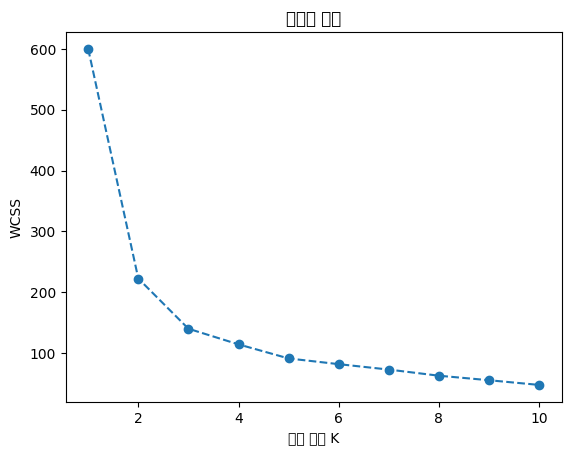

In [3]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):                # K=1~10 테스트
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)          # 군집 내 응집도

plt.plot(range(1, 11), wcss, marker="o", linestyle="--")
plt.xlabel("군집 개수 K"); plt.ylabel("WCSS")
plt.title("엘보우 방법"); plt.show()
# 그래프가 꺾이는 지점(iris는 보통 K=3)이 최적 후보

In [4]:
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)     # 각 점의 군집 번호
df["cluster"] = labels

score = silhouette_score(X_scaled, labels)
print(f"실루엓 계수: {score:.3f}")    # 1에 가까울수록 잘 분리

실루엓 계수: 0.460


c:\Users\it\Documents\bigdata\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\it\Documents\bigdata\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


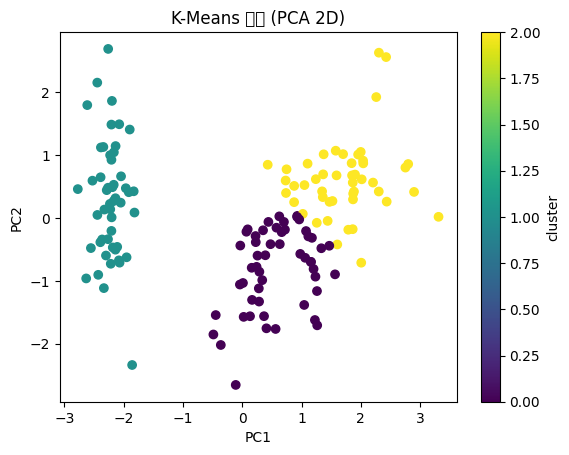

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)       # 4차원 → 2차원
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("K-Means 군집 (PCA 2D)"); plt.colorbar(label="cluster"); plt.show()